In [1]:
import slangpy as spy
import numpy as np
import quaternion
import pathlib
import matplotlib.pyplot as plt
from pyglm import glm
from PIL import Image
import jax
import jax.numpy as jnp

from bvhgs.camera import Camera
from bvhgs.renderer import Renderer
from bvhgs.gaussian import GaussianCloud
from bvhgs.data import SFMDataset

[INFO] (rhi) layer: CreateDevice: Debug layer is enabled.
[WARN] No supported shader model found, pretending to support sm_6_0.


# Load a COLMAP DB

In [2]:
sfm_dataset = SFMDataset()
sfm_dataset.load_from_colmap(
    colmap_path=pathlib.Path("../resources/dataset/tandt_db/tandt/truck/sparse/0/"),
    image_dir=pathlib.Path("../resources/dataset/tandt_db/tandt/truck/images/")
)

In [3]:
camera, image_path = sfm_dataset[-1]
camera.to_slang()

{'_rotation': [-0.03458227962255478,
  0.32694852352142334,
  0.0032672483939677477,
  0.9444036483764648],
 '_translation': vec3( -1.23324, -0.470908, 3.94508 ),
 '_sensorSize': uvec2( 979, 546 ),
 '_focalLength': 581.9245354745742,
 '_nearPlane': 0.1,
 '_farPlane': 1000.0}

In [4]:
# Load the image.
image = Image.open(image_path)

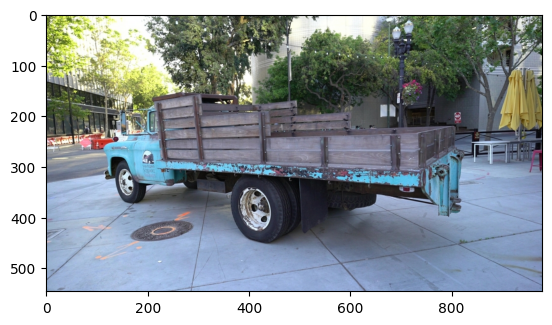

In [5]:
image_arr = np.array(image)
image_arr = image_arr.astype(np.float32) / 255
plt.imshow(image_arr)

# Load COLMAP Point Cloud

In [6]:
gaussians = GaussianCloud()
gaussians.load_from_colmap(pathlib.Path("../resources/dataset/tandt_db/tandt/truck/sparse/0/"))
len(gaussians)

104692

# Renderer

In [7]:
renderer = Renderer(gaussians, camera)

In [8]:
renderer.render()

[WARN] (rhi) slang: metal 32023.619: /Users/fangjun/Documents/stanford/bvhgs/src/bvhgs/slang/./renderer/tile.slang(75): warning :  unused variable '_S1' [-Wunused-variable]
    uint _S1 = atomic_fetch_add_explicit((&kernelContext_0)->g_tile_hist_atomic_0+uint(((*((&kernelContext_0)->g_gaussian_table_0+tid_1)).key_0) >> 32U), 1U, memory_order_relaxed);
         ^
1 warning generated.



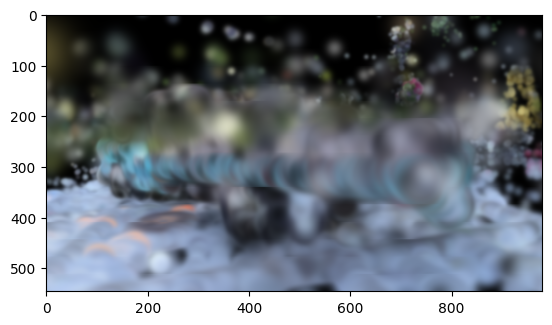

In [9]:
render_arr = renderer.render_target.to_numpy()[:, :, :3]
plt.imshow(render_arr)

# Image Lnoss

In [10]:
def image_loss(src: jnp.ndarray, dst: jnp.ndarray):
    return jnp.mean((dst - src)**2)

In [11]:
image_loss(render_arr, image_arr)

Array(0.09586811, dtype=float32)

In [12]:
# Image grad.
loss_grad = jax.value_and_grad(image_loss)

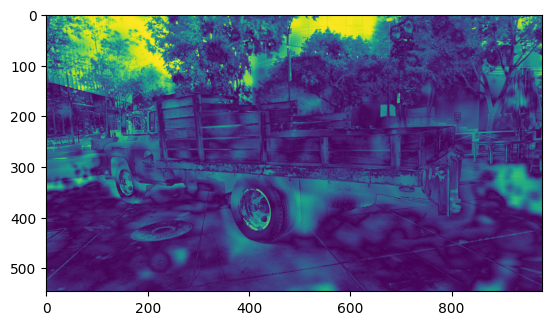

In [13]:
loss, render_target_grad = loss_grad(render_arr, image_arr)
plt.imshow(jnp.linalg.norm(render_target_grad, axis=-1))

## A Very Simple Gradient Descent

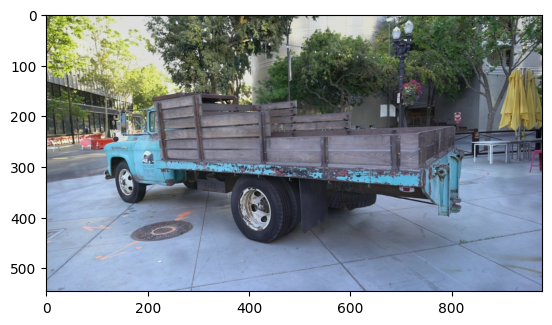

In [14]:
lr = 5e4
num_epochs = 32

for i in range(num_epochs):
    loss, render_target_grad = loss_grad(render_arr, image_arr)
    render_arr -= render_target_grad * lr

plt.imshow(render_arr)